# 01 · Price Data Pipeline & Data Quality

**Goal:** understand the stock price data pulled by `src/fetch_prices.py` and check it's trustworthy before any analysis.
In finance, one bad price (an unadjusted split, a stale holiday row) can create a fake 90% "crash" or a fake "profit".

Run `python src/fetch_prices.py` in the terminal first.

In [1]:
import sys
from pathlib import Path
import duckdb
import pandas as pd
import matplotlib.pyplot as plt

sys.path.append("../src")
from chart_style import apply_style, save, COLORS, PALETTE
apply_style()

con = duckdb.connect(str(Path("..") / "data" / "portfolio.duckdb"), read_only=True)
def sql(query):
    return con.sql(query).df()

## 1. The stock universe
27 large, liquid NSE stocks across 11 sectors, plus the **Nifty 50 index** (`^NSEI`) as the benchmark we compare against.
It's defined in `config/universe.csv`, so to analyse different stocks you just edit that file and re-run the pipeline.

In [2]:
sql("""
    SELECT sector, COUNT(*) AS stocks, STRING_AGG(name, ', ') AS companies
    FROM raw.universe
    GROUP BY sector
    ORDER BY stocks DESC
""")

,sector,stocks,companies
0,Financials,5,"HDFC Bank, ICICI Bank, State Bank of India, Ko..."
1,IT,4,"Tata Consultancy Services, Infosys, HCL Techno..."
2,Healthcare,3,"Sun Pharma, Dr. Reddy's Laboratories, Cipla"
3,Auto,3,"Maruti Suzuki, Mahindra & Mahindra, Bajaj Auto"
4,Energy,3,"Reliance Industries, NTPC, Oil & Natural Gas Corp"
5,Consumer Staples,3,"Hindustan Unilever, ITC, Nestle India"
6,Consumer Discretionary,2,"Asian Paints, Titan Company"
7,Materials,2,"Tata Steel, UltraTech Cement"
8,Benchmark,1,Nifty 50 Index
9,Telecom,1,Bharti Airtel


## 2. What one row looks like: OHLCV
Each row is **one stock on one trading day**:
- **Open / High / Low / Close**: first, highest, lowest and last traded price of the day (₹)
- **Volume**: number of shares traded

We'll mostly use **Close**, the price everyone agrees on at the end of the day.

In [3]:
sql("SELECT * FROM raw.prices WHERE ticker = 'RELIANCE.NS' ORDER BY date DESC LIMIT 5")

,date,ticker,open,high,low,close,volume
0,2026-09-25,RELIANCE.NS,1210.500000,1227.400024,1210.500000,1226.000000,13138735.0
1,2026-09-24,RELIANCE.NS,1236.599976,1241.599976,1219.199951,1219.199951,13923795.0
2,2026-09-23,RELIANCE.NS,1242.000000,1252.800049,1238.900024,1248.000000,8352048.0
3,2026-09-22,RELIANCE.NS,1247.599976,1251.900024,1237.400024,1240.400024,10684376.0
4,2026-09-21,RELIANCE.NS,1234.099976,1249.099976,1232.500000,1247.400024,10007218.0


## 3. Why *adjusted* prices matter
Companies change their share count through **splits** and **bonus issues** (e.g. 1 share becomes 10, so the price drops ~90% overnight but nobody lost money),
and they pay **dividends** (cash to shareholders, after which the price drops by roughly that amount).

**Adjusted prices** rewrite history so the whole series is comparable: returns then reflect what an investor actually earned.
We downloaded adjusted prices (`auto_adjust=True`). Here's how big the difference is for ITC, a high-dividend stock:

In [4]:
import yfinance as yf
itc = yf.download("ITC.NS", start="2016-01-01", auto_adjust=False, progress=False)
price_only   = itc["Close"].iloc[:, 0]        # price ignoring dividends
total_return = itc["Adj Close"].iloc[:, 0]    # price adjusted for dividends

print(f"ITC price growth since 2016:         {price_only.iloc[-1] / price_only.iloc[0]:.2f}x")
print(f"ITC total return (with dividends):   {total_return.iloc[-1] / total_return.iloc[0]:.2f}x")

ITC price growth since 2016:         1.28x
ITC total return (with dividends):   1.88x


**Finding:** for ITC, ignoring dividends would **massively understate** the return (roughly 1.3× vs 1.9×). Using adjusted prices is non-negotiable.

## 4. Completeness checks

In [5]:
coverage = sql("""
    SELECT ticker,
           MIN(date)            AS first_date,
           MAX(date)            AS last_date,
           COUNT(*)             AS trading_days,
           COUNT(*) - COUNT(close) AS missing_close
    FROM raw.prices
    GROUP BY ticker
    ORDER BY trading_days
""")
coverage

,ticker,first_date,last_date,trading_days,missing_close
0,^NSEI,2016-01-04,2026-09-25,2645,0
1,TATASTEEL.NS,2016-01-01,2026-09-25,2656,0
2,DRREDDY.NS,2016-01-01,2026-09-25,2656,0
3,M&M.NS,2016-01-01,2026-09-25,2656,0
4,ULTRACEMCO.NS,2016-01-01,2026-09-25,2656,0
5,INFY.NS,2016-01-01,2026-09-25,2656,0
6,MARUTI.NS,2016-01-01,2026-09-25,2656,0
7,TCS.NS,2016-01-01,2026-09-25,2656,0
8,CIPLA.NS,2016-01-01,2026-09-25,2656,0
9,NTPC.NS,2016-01-01,2026-09-25,2656,0


In [6]:
sql("""
    SELECT
        (SELECT COUNT(*) - COUNT(DISTINCT (ticker, date)) FROM raw.prices)            AS duplicate_rows,
        (SELECT COUNT(*) FROM raw.prices WHERE close <= 0)                             AS non_positive_prices,
        (SELECT COUNT(*) FROM raw.prices
          WHERE low > high OR close > high * 1.0001 OR close < low * 0.9999)           AS impossible_ohlc
""")

,duplicate_rows,non_positive_prices,impossible_ohlc
0,0,0,0


**Finding:** every ticker has full history since Jan 2016, with no duplicates, no zero or negative prices, and no impossible rows (e.g. close above the day's high).

## 5. The trading calendar
Markets are closed on weekends and holidays, so a year has only **~245–250 trading days**, not 365. Annualising returns later uses this number.

In [7]:
sql("""
    SELECT YEAR(date) AS year, COUNT(DISTINCT date) AS trading_days
    FROM raw.prices
    WHERE ticker = '^NSEI'
    GROUP BY year ORDER BY year
""")

,year,trading_days
0,2016,244
1,2017,248
2,2018,245
3,2019,241
4,2020,250
5,2021,248
6,2022,248
7,2023,245
8,2024,246
9,2025,249


### ⚠️ Issue: "phantom" holiday rows
Some dates have rows for the stocks but not for the Nifty index. Let's look at them, plus rows with **zero volume**:

In [8]:
phantom = sql("""
    WITH p AS (
        SELECT *, LAG(close) OVER (PARTITION BY ticker ORDER BY date) AS prev_close
        FROM raw.prices
        WHERE ticker <> '^NSEI'
    )
    SELECT date,
           COUNT(*)                                        AS stock_rows,
           SUM(CASE WHEN volume = 0 THEN 1 ELSE 0 END)     AS zero_volume_rows,
           SUM(CASE WHEN volume = 0 AND close = prev_close THEN 1 ELSE 0 END) AS zero_volume_and_unchanged,
           date NOT IN (SELECT date FROM raw.prices WHERE ticker = '^NSEI') AS index_missing
    FROM p
    GROUP BY date
    HAVING SUM(CASE WHEN volume = 0 THEN 1 ELSE 0 END) > 0
        OR date NOT IN (SELECT date FROM raw.prices WHERE ticker = '^NSEI')
    ORDER BY date
""")
phantom

,date,stock_rows,zero_volume_rows,zero_volume_and_unchanged,index_missing
0,2016-01-01,27,0.0,0.0,True
1,2016-08-12,27,0.0,0.0,True
2,2018-01-01,27,0.0,0.0,True
3,2019-01-01,27,0.0,0.0,True
4,2019-10-27,27,0.0,0.0,True
5,2020-11-14,27,0.0,0.0,True
6,2024-01-15,27,1.0,1.0,False
7,2025-03-18,27,26.0,26.0,False
8,2025-09-08,27,1.0,1.0,False
9,2026-01-15,27,27.0,27.0,True


**Finding:** two kinds of odd dates:
1. **Zero volume + unchanged price.** The data provider filled in market holidays with a copy of the previous day. No trading happened, so these rows would add fake **0% return days** and slightly understate volatility.
2. **Index missing but stocks traded.** Includes special sessions like Diwali **Muhurat trading** (e.g. 27 Oct 2019, 14 Nov 2020, which fell on weekends) and a few dates where the index series simply has gaps.

**Decision (applied in the next step's cleaning):** drop zero-volume-unchanged rows, and analyse on a **common calendar**: only dates where the Nifty index has data.
Returns across a skipped date are still correct because they're computed close-to-close on the calendar.

## 6. Extreme daily moves: errors or real events?
A daily move above ±15% in a large-cap stock is rare. It's either a **data error** (e.g. an unadjusted split would show about −50% or −90%) or a **real event**. We must check.

In [9]:
big_moves = sql("""
    WITH r AS (
        SELECT ticker, date,
               close / LAG(close) OVER (PARTITION BY ticker ORDER BY date) - 1 AS daily_return
        FROM raw.prices
    )
    SELECT r.ticker, u.name, r.date, ROUND(100 * r.daily_return, 1) AS move_pct
    FROM r JOIN raw.universe u ON r.ticker = u.ticker
    WHERE ABS(r.daily_return) > 0.15
    ORDER BY ABS(r.daily_return) DESC
""")
big_moves

,ticker,name,date,move_pct
0,SBIN.NS,State Bank of India,2017-10-25,27.7
1,BAJFINANCE.NS,Bajaj Finance,2020-03-23,-23.2
2,TITAN.NS,Titan Company,2017-11-06,18.8
3,ONGC.NS,Oil & Natural Gas Corp,2020-03-20,18.5
4,ICICIBANK.NS,ICICI Bank,2020-03-23,-17.8
5,TITAN.NS,Titan Company,2017-06-05,17.0
6,MARUTI.NS,Maruti Suzuki,2020-03-23,-16.9
7,M&M.NS,Mahindra & Mahindra,2020-04-09,16.9
8,ONGC.NS,Oil & Natural Gas Corp,2024-06-04,-16.8
9,WIPRO.NS,Wipro,2020-07-15,16.8


**Finding:** every extreme move matches a real market event, so **none are data errors**:
- **23 Mar 2020:** the COVID crash (banks, autos and L&T all fell 16–23% in one day)
- **25 Oct 2017:** SBI +28% after the government announced a ₹2.1 lakh crore bank recapitalisation plan
- **4 Jun 2024:** general election results day (PSU stocks like ONGC and NTPC fell ~16%)
- **22 Oct 2019:** Infosys −16% on whistleblower allegations

No move looks like a split artefact (−50% / −90%), which confirms the adjustment worked. These real shocks stay in the data, and we'll study the COVID crash in the risk analysis.

## 7. First look: ten years of growth
To compare stocks with very different prices (₹200 vs ₹10,000), we **rebase** each series to 100 on the first day: `price / first_price × 100`.
A line at 300 means the investment tripled.

Nifty 50 grew 3.0x since Jan 2016
Stocks that beat the Nifty: 16 of 27


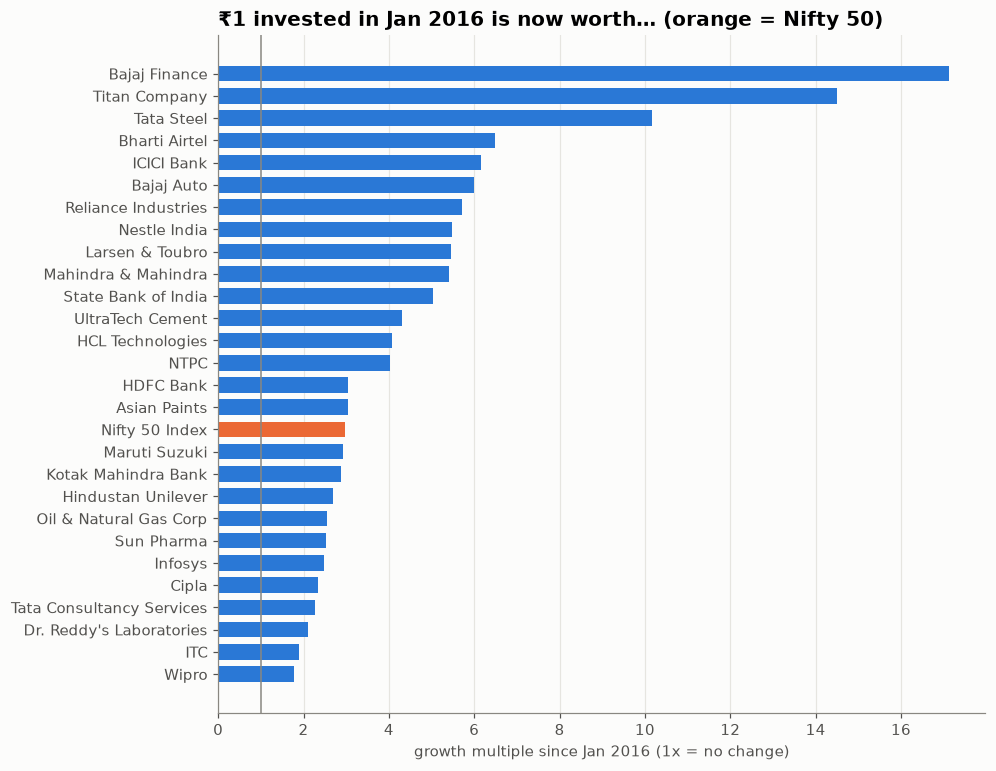

In [10]:
prices = sql("""
    SELECT p.date, u.name, p.close
    FROM raw.prices p JOIN raw.universe u ON p.ticker = u.ticker
    WHERE p.date IN (SELECT date FROM raw.prices WHERE ticker = '^NSEI')
""")
wide = prices.pivot(index="date", columns="name", values="close")      # one column per stock
rebased = wide / wide.iloc[0] * 100

growth = (rebased.iloc[-1] / 100).sort_values()
print(f"Nifty 50 grew {growth['Nifty 50 Index']:.1f}x since Jan 2016")
print(f"Stocks that beat the Nifty: {(growth.drop('Nifty 50 Index') > growth['Nifty 50 Index']).sum()} of {len(growth) - 1}")

fig, ax = plt.subplots(figsize=(9, 8))
colors = [COLORS["orange"] if n == "Nifty 50 Index" else COLORS["blue"] for n in growth.index]
ax.barh(growth.index, growth.values, color=colors, height=0.7)
ax.axvline(1, color=COLORS["grey"], linewidth=1)
ax.grid(axis="x"); ax.grid(axis="y", visible=False)
ax.set_xlabel("growth multiple since Jan 2016 (1x = no change)")
ax.set_title("₹1 invested in Jan 2016 is now worth… (orange = Nifty 50)")
save(fig, "01_growth_multiple")
plt.show()

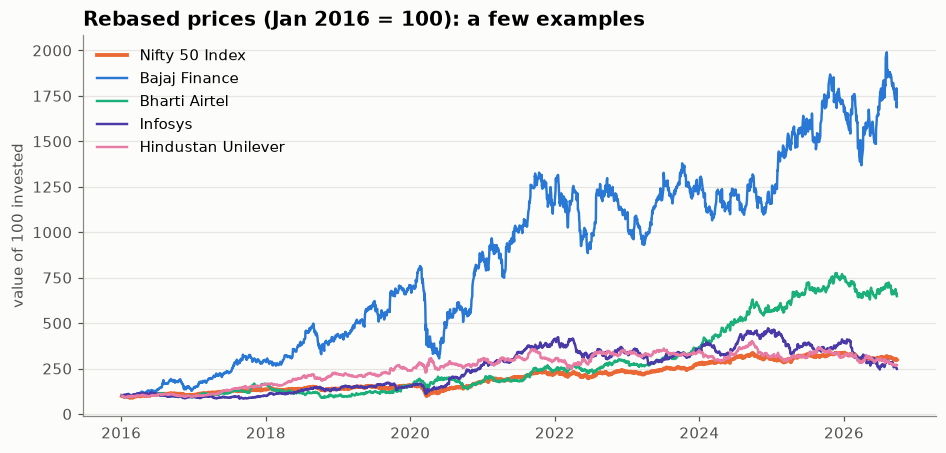

In [11]:
picks = ["Nifty 50 Index", "Bajaj Finance", "Bharti Airtel", "Infosys", "Hindustan Unilever"]
fig, ax = plt.subplots()
for name, col in zip(picks, [COLORS["orange"], COLORS["blue"], COLORS["aqua"], COLORS["violet"], COLORS["magenta"]]):
    ax.plot(rebased.index, rebased[name], label=name, color=col, linewidth=2.5 if name == "Nifty 50 Index" else 1.6)
ax.set_title("Rebased prices (Jan 2016 = 100): a few examples")
ax.set_ylabel("value of 100 invested")
ax.legend(loc="upper left")
save(fig, "02_rebased_examples")
plt.show()

### ⚠️ Caveat 1: survivorship bias
16 of 27 stocks beat the Nifty. Impressive? Not really: we picked stocks that are **large and successful today**, and companies that
shrank or were dropped from the index over the last 10 years aren't in our list. Looking backwards with today's winners always flatters the results.
This is called **survivorship bias**, and it's why the optimisation later will be tested only on data *after* the period it learns from.

### ⚠️ Caveat 2: the benchmark excludes dividends
Our **stock** prices are adjusted for dividends (total return), but Yahoo's `^NSEI` is the Nifty 50 **price** index, which *excludes* dividends
(the dividend-inclusive "Total Return Index" isn't available on Yahoo). Nifty dividends are roughly 1–1.5% a year, so comparisons slightly **flatter the stocks**
against the benchmark. We keep this in mind and state it whenever we compare with the Nifty.

---
## Summary: data quality decisions
| # | Check | Result | Decision |
|---|---|---|---|
| 1 | Splits, bonuses & dividends | Raw prices would understate returns (ITC: 1.3× vs 1.9×) | Use **adjusted** prices |
| 2 | Missing history / duplicates / impossible OHLC | None found | No action |
| 3 | Holiday rows filled by the provider (zero volume, unchanged price) | A few dates | **Drop** them |
| 4 | Dates missing for the index (incl. Muhurat sessions) | 11 dates | Use a **common calendar** (index trading days) |
| 5 | Extreme moves > ±15% | All real events (COVID, elections, SBI recap) | **Keep** them |
| 6 | Benchmark is a price index (no dividends) | Understates Nifty returns by ~1–1.5%/yr | Keep, but **state the caveat** in every comparison |
| 7 | Universe = today's large caps (survivorship bias) | Past performance looks better than it really was | State it; judge strategies only on **out-of-sample** data |

Next: notebook 02 builds clean daily returns and compares each stock's performance with the Nifty 50.

In [ ]:
con.close()